In [7]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W]
    pressure_loss_fit_factor=30.0,  # [-]

    # Geometrie Parameters
    fin_pitch=0.008,  # [m]
    fin_height=0.08,  # [m]
    fin_length=0.08,  # [m]
    fin_thickness=0.00012,  # [m]
    fin_amount=20,  # [-]
    fin_thermal_conductivity=200.0,  # [W/mK]
    tube_outer_diameter=0.010,  # [m]
    tube_inner_diameter=0.006,  # [m]
    tube_layers=2,  # [-]
    tubes_per_layer=2,  # [-]
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################
refrigerant_inputs = RefrigerantInputs(
    h_in = 265000.0,  # [J/kg]
    p_eva = 3.0e5,  # [Pa]
    m_dot= 0.005,  # [kg/s]
)

# Define the inputs for the frost evaporator
air_inputs = AirInputs(
    T_in  = 280.0,  # [K]
    p_in  = 101325.0,  # [Pa]
    R_in  = 0.85,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)


frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
from tqdm import tqdm



# for j in tqdm(range(5000)):
#     converged = False  # Flag to track if we found a stable solution
    
#     # --- 2. Inner loop to converge ---
#     for i in range(200):
#         T_prev = state.hmt.T_frost_surface
#         # Run your model updates
#         frost_model.update_properties(state, inputs)
#         air_model.update_properties(state, inputs)
#         refrigerant_model.update_properties(state, inputs)
#         hmt_model.update_properties(state, inputs)
#         thermo_model.update_properties(state, inputs)
        
#         # Get the *new* value
#         T_new = state.hmt.T_frost_surface

#         T_frost_surface_history_all.append(T_new)
        
#         # --- 3. The convergence check ---
#         error = abs(T_new - T_prev)
#         if error < 1e-2 :
#             converged = True  # We found a stable solution!
#             break             # Exit the inner loop
    
#     # --- 4. Handle non-convergence ---
#     if not converged:
#         print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
#         print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")
#         print(params.__str__())
#         print("\n\n\n\n")
#         print(inputs.__str__())
#         print("\n\n\n\n")
#         print(state.__str__())        
#         break 

#     states_history.append(state.copy())
    
#     # Now that we have a converged state, take the physical step forward
#     frost_model.step_forward(state, inputs)

# print("\n\n\n\nSimulation complete.")

# print("\n\nFinal State:\n")

# print(params.__str__())
# print("\n\n\n\n")
# print(inputs.__str__())
# print("\n\n\n\n")
# print(state.__str__())



import time
from tqdm import tqdm

# 1. Setup für das Tracking der Zeiten
execution_times = {
    "frost_model": 0.0,
    "air_model": 0.0,
    "refrigerant_model": 0.0,
    "hmt_model": 0.0,
    "thermo_model": 0.0
}

for j in tqdm(range(4000)):
    converged = False  # Flag to track if we found a stable solution
    
    # --- 2. Inner loop to converge ---
    for i in range(200):
        T_prev = state.hmt.T_frost_surface
        
        # --- Run your model updates with TIMING ---
        
        # Messung Frost Model
        t_start = time.perf_counter()
        frost_model.update_properties(state, inputs)
        execution_times["frost_model"] += time.perf_counter() - t_start
        
        # Messung Air Model
        t_start = time.perf_counter()
        air_model.update_properties(state, inputs)
        execution_times["air_model"] += time.perf_counter() - t_start
        
        # Messung Refrigerant Model
        t_start = time.perf_counter()
        refrigerant_model.update_properties(state, inputs)
        execution_times["refrigerant_model"] += time.perf_counter() - t_start
        
        # Messung HMT Model
        t_start = time.perf_counter()
        hmt_model.update_properties(state, inputs)
        execution_times["hmt_model"] += time.perf_counter() - t_start
        
        # Messung Thermo Model
        t_start = time.perf_counter()
        thermo_model.update_properties(state, inputs)
        execution_times["thermo_model"] += time.perf_counter() - t_start
        
        # ------------------------------------------
        
        # Get the *new* value
        T_new = state.hmt.T_frost_surface

        T_frost_surface_history_all.append(T_new)
        
        # --- 3. The convergence check ---
        error = abs(T_new - T_prev)
        if error < 1e-2 :
            converged = True  # We found a stable solution!
            break             # Exit the inner loop
    
    # --- 4. Handle non-convergence ---
    if not converged:
        print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
        print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")
        print(params.__str__())
        print("\n\n\n\n")
        print(inputs.__str__())
        print("\n\n\n\n")
        print(state.__str__())        
        break 

    states_history.append(state.copy())
    
    # Now that we have a converged state, take the physical step forward
    frost_model.step_forward(state, inputs)

# --- AUSWERTUNG AM ENDE ---
print("\n" + "="*30)
print("PERFORMANCE ANALYSE (Gesamtlaufzeit pro Modell)")
print("="*30)

# Sortieren von langsam nach schnell
sorted_times = sorted(execution_times.items(), key=lambda item: item[1], reverse=True)
total_measured_time = sum(execution_times.values())

for model_name, duration in sorted_times:
    percent = (duration / total_measured_time) * 100 if total_measured_time > 0 else 0
    print(f"{model_name:<20}: {duration:.4f} s ({percent:.1f}%)")
print("="*30)

TypeError: FrostEvaporatorParameters.__init__() got an unexpected keyword argument 'pressure_loss_fit_factor'

# Simulation of Paper: "First-principles modeling of frost accumulation on fan-supplied tube-fin evaporators"

In [1]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=20.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    correction_factor_h_conv_air=0.7,
    correction_factor_surface_density=1,
    correction_factor_eta_fin=1,
    correction_factor_k_frost=1,
    correction_factor_pressure_loss=3.4,

    # Geometrie Parameters
    # Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_pitch=0.0025,  # [m]
    # Paper: Height = 152 mm
    fin_height=0.152,  # [m]
    # Paper: Depth (air flow length) = 45 mm
    fin_length=0.045,  # [m]
    # Paper: 0.2 mm thickness
    fin_thickness=0.0002,  # [m]
    # Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_amount=128,  # [-]
    # Paper: "Aluminum alloy" (Standard value usually ~200-220)
    fin_thermal_conductivity=200.0,  # [W/mK]
    # Paper: 10 mm Outer Diameter
    tube_outer_diameter=0.010,  # [m]
    # Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_inner_diameter=0.008,  # [m]
    # Paper: "Two rows"
    tube_layers=2,  # [-]
    # Paper: "Six tubes per row"
    tubes_per_layer=6,  # [-]
    # Paper: Copper tubes (Standard value ~385-400)
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the frost evaporator
# Values below are for "Test 2" (Standard Commercial conditions from Table 1)
air_inputs = AirInputs(
    T_in  = 273.15 + 7,  # [K]
    p_in  = 101325.0,  # [Pa]
    R_in  = 0.85,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)
state.hmt.set("T_frost_base", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("reynolds", 2000)
state.air.set("T_dew_point", 260)

state.frost.set("density", 100)
state.frost.set("mass", 1e-9)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

# DELETE
T_surface_temporary = 273.15 - 10
state.refrigerant.set("T_in", T_surface_temporary)
state.refrigerant.set("T_out", T_surface_temporary)

frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
history_residual = []
velocity_history = []
total_iterations = 0
from tqdm import tqdm

simulation_duration = 42*3 #60 # [s]

for j in tqdm(range(simulation_duration)):
    converged = False  # Flag to track if we found a stable solution
    
    # Inner loop to converge
    for i in range(200):

        # Get the *previous* value
        T_prev = state.hmt.T_frost_surface

        # Run your model updates
        frost_model.update_properties(state, inputs)
        air_model.update_properties(state, inputs)
        # refrigerant_model.update_properties(state, inputs)
        hmt_model.update_properties(state, inputs)
        thermo_model.update_properties(state, inputs)
        
        # Get the *new* value
        T_new = state.hmt.T_frost_surface
        T_frost_surface_history_all.append(T_new)
        
        # The convergence check
        res = abs(T_new - T_prev)      
        history_residual.append(res)  
        velocity_history.append(state.air.velocity)

        error = abs(T_new - T_prev)
        if error < 1e-3 :
            converged = True  # We found a stable solution!
            total_iterations += i+1
            break             # Exit the inner loop

    # Handle non-convergence
    if not converged:
        print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
        print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")        
        break 

    if state.air.m_dot_humid < 1e-3:
        print(f"\n\n\n\n!!! Air Choke bei Zeitschritt j={j} !!!")
        print(f"Letzter Massenstorm: {state.air.m_dot_humid}\n")        
        break 

    states_history.append(state.copy())
    
    # Now that we have a converged state, take the physical step forward
    frost_model.step_forward(state, inputs)

print("\n\nFinal State:\n")
print(f"Average Iterations per Timestep: {(total_iterations/simulation_duration)} \n" )
print(params.__str__())
print("\n\n\n\n")
print(inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

# plt.figure()
# plt.plot(history_residual)
# plt.yscale('log')
# plt.title("History of Residuals")
# plt.show()

print(3600 * state.air.m_dot_humid / state.air.density_avg)

Model initialized with fluid: Propane


100%|██████████| 126/126 [00:04<00:00, 25.21it/s]



Final State:

Average Iterations per Timestep: 8.30952380952381 

FrostEvaporatorParameters:
time_step=20.0 s (Simulation time step for evaporator model)
gravity=9.81 m/s^2 (Gravitational acceleration)
water_freezing_point=273.15 K (The freezing point temperature of water.)
frost_density_correlation_choice=da_silva_paper - (Choice of correlation for frost density)
frost_thickness_correlation_choice=jonas_diss - (Choice of correlation for frost thickness)
frost_conductivity_correlation_choice=A - (Choice of correlation for frost thermal conductivity)
correction_factor_h_conv_air=0.7 - (Correction factor to scale h_conv of air)
correction_factor_surface_density=1 - (Correction factor to scale the frost surface density)
correction_factor_eta_fin=1 - (Correction factor to scale the fin efficiency)
correction_factor_k_frost=1 - (Correction factor to scale the frost heat transfer)
correction_factor_pressure_loss=3.4 - (Correction factor to scale the air-side pressure loss)
ambient_pressure

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
n_steps = len(states_history)
dt = params.time_step 
# Convert time to minutes for the axis
time_axis = [i * dt / 60 for i in range(n_steps)]

data = {
    # --- TEMPS ---
    'T_air_in': inputs.air.T_in, 
    'T_air_out': [s.air.T_out for s in states_history],
    'T_frost_surf': [s.hmt.T_frost_surface for s in states_history],
    'T_refrigerant_in' : [s.refrigerant.T_in for s in states_history],
    'T_refrigerant_out' : [s.refrigerant.T_out for s in states_history],

    # --- HUMIDITY ---
    'W_in': state.air.W_in, 
    'W_out': [s.air.W_out for s in states_history],
    'W_frost_sat': [s.air.W_frost_surface_sat for s in states_history],
    
    # --- HEAT TRANSFER ---
    'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
    'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],

    # --- HEAT RESISTANCES ---
    'R_air': [s.hmt.R_air for s in states_history],
    'R_frost': [s.hmt.R_frost for s in states_history],
    'R_downstream': [s.hmt.R_downstream for s in states_history],
    'R_total':[s.hmt.R_downstream + s.hmt.R_air for s in states_history],
    'R_air_ratio': [s.hmt.R_air / (s.hmt.R_downstream + s.hmt.R_air) for s in states_history],
    'R_frost_ratio': [s.hmt.R_frost / (s.hmt.R_downstream + s.hmt.R_air) for s in states_history],


    # --- FROST PROPERTIES ---
    'thickness': [s.frost.thickness for s in states_history],
    'density': [s.frost.density for s in states_history],
    'space': [s.frost.space_between_frost for s in states_history],
    'mass': [s.frost.mass for s in states_history],
    'm_dot_densification': [s.hmt.m_dot_densification for s in states_history],
    'm_dot_thickening': [s.hmt.m_dot_thickening for s in states_history],
    
    # --- PHYSICS / FLOW ---
    'h_conv': [s.air.h_conv for s in states_history],
    'eta_fin': [s.hmt.eta_fin for s in states_history],
    'velocity': [s.air.velocity for s in states_history],
    'm_dot': [s.air.m_dot_humid for s in states_history],
    'p_delta': [s.air.p_in - params.ambient_pressure for s in states_history],
    'vol_flow': [3600 * s.air.m_dot_humid / s.air.density_avg for s in states_history],    # Formula: 3600 * m_dot / density
}

df = pd.DataFrame(data)
df['Time'] = time_axis
df.set_index('Time', inplace=True)

# ---------------------------------------------------------
# 2. PLOT CONFIGURATION (Reordered for Logic)
# ---------------------------------------------------------
plots_config = [
    # --- ROW 1 General ---
    (1, 1, ['T_air_in', 'T_air_out', 'T_frost_surf', 'T_refrigerant_in', 'T_refrigerant_out'], "Temperatures [K]"), 
    (1, 2, ['Q_dot_total', 'Q_dot_sens'], "Heat Transfer [W]"),
    (1, 3, ['W_in', 'W_out', 'W_frost_sat'], "Abs. Humidity [kg/kg]"),
    (1, 4, ['eta_fin'], "Fin Efficiency [-]"),
    (1, 5, ['R_total'], "Total Heat Resistance [K/W]"),
    # (1, 5, ['R_air_ratio', 'R_frost_ratio'], "Heat Resistance Ratios"),
    
    # --- ROW 2 Air ---
    (2, 1, ['p_delta'], "Pressure Difference [Pa]"),
    (2, 2, ['vol_flow'], "Volume Flow [m³/h]"),
    (2, 3, ['velocity'], "Air Velocity [m/s]"),
    (2, 4, ['m_dot'], "Mass Flow [kg/s]"),
    (2, 5, ['h_conv'], "Air h_conv [W/m²K]"),
    
    # --- ROW 3 Frost ---
    (3, 1, ['mass'], "Frost Mass [kg]"),
    (3, 2, ['m_dot_densification', 'm_dot_thickening'], "Split of Frost Mass Flows"),
    (3, 3, ['thickness'], "Frost Thickness [m]"),
    (3, 4, ['density'], "Frost Density [kg/m³]"),
    (3, 5, ['space'], "Space Between Frost [m]"),

]

fig = make_subplots(
    rows=3, cols=5, 
    subplot_titles=[p[3] for p in plots_config],
    vertical_spacing=0.1, horizontal_spacing=0.05
)

for row, col, cols_to_plot, title in plots_config:
    for col_name in cols_to_plot:
        # Optional: styling for T_dew_point if you add it back later
        line_style = dict(dash='dot', width=2) if col_name == 'T_dew_point' else dict()
        
        fig.add_trace(
            go.Scatter(
                x=df.index, y=df[col_name], name=col_name,
                line=line_style,
                legendgroup=title, legendgrouptitle_text=title
            ),
            row=row, col=col
        )

# ---------------------------------------------------------
# 3. LAYOUT & INTERACTIVITY
# ---------------------------------------------------------
fig.update_layout(
    height=800, width=1400, 
    hovermode="x unified",
    showlegend=False,
    margin=dict(
        l=20, # left margin
        r=20, # right margin
        t=30, # top margin 
        b=20, # bottom margin
    )
)

fig.update_xaxes(matches='x')
fig.update_xaxes(title_text="Time [min]", row=3)
fig.update_yaxes(rangemode="tozero", row=3, col=3)
fig.show()

# Run Multiple Simulations and Plot (Da Silva)

In [7]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modules
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel

#############################################################################
# 1. Define Global Parameters (Hardware/Geometry - constant for all tests)
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,   # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    correction_factor_h_conv_air=0.55,
    correction_factor_surface_density=1.5,
    correction_factor_eta_fin=0.9,
    correction_factor_k_frost=1,
    pressure_loss_fit_factor=3.2,  # [-]


    # Geometry Parameters
    fin_pitch=0.0025,               # [m]
    fin_height=0.152,               # [m]
    fin_length=0.045,               # [m]
    fin_thickness=0.0002,           # [m]
    fin_amount=128,                 # [-]
    fin_thermal_conductivity=200.0, # [W/mK]
    tube_outer_diameter=0.010,      # [m]
    tube_inner_diameter=0.008,      # [m]
    tube_layers=2,                  # [-]
    tubes_per_layer=6,              # [-]
    tube_thermal_conductivity=400,  # [W/mK]

    alpha_0=4300.0,  # [W/m^2K]
)

#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the simulation for a specific set of boundary conditions.
    Returns a DataFrame of results and the assigned color for plotting.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    # Dummy refrigerant inputs (since T_surface is constant/forced)
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    air_inputs = AirInputs(
        T_in = 273.15 + T_air_C,  # Convert to K
        p_in = 101325.0,          # [Pa]
        R_in = RH_in,             # [-]
    )

    inputs = FrostEvaporatorInputs(
        air_inputs=air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    # refrigerant_model = RefrigerantModel(params, propane_RP) # Not strictly needed if forcing T_surf
    hmt_model = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)

    # --- Initial State ---
    state = FrostEvaporatorState()
    state = FrostEvaporatorState()
    state.hmt.set("T_frost_surface", 268)
    state.hmt.set("T_frost_base", 268)
    state.air.set("T_out", inputs.air.T_in)
    state.air.set("reynolds", 2000)
    state.air.set("T_dew_point", 260)
    state.frost.set("density", 100)
    state.frost.set("mass", 1e-9)

    state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

    # FORCE SURFACE TEMPERATURE (The paper's method)
    T_surface_kelvin = 273.15 + T_surf_C
    state.refrigerant.set("T_in", T_surface_kelvin)
    state.refrigerant.set("T_out", T_surface_kelvin)

    # Initial Step
    frost_model.step_forward(state, inputs)

    # --- Time Loop ---
    states_history = []
    simulation_duration_sec = int(duration_mins * 60)
    
    # Use a unique description for the progress bar
    for j in tqdm(range(simulation_duration_sec), desc=case_name):
        converged = False
        
        # Inner loop to converge
        for i in range(200):
            T_prev = state.hmt.T_frost_surface

            # Run model updates
            frost_model.update_properties(state, inputs)
            air_model.update_properties(state, inputs)
            hmt_model.update_properties(state, inputs)
            thermo_model.update_properties(state, inputs)
            
            T_new = state.hmt.T_frost_surface
            
            if abs(T_new - T_prev) < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residuum: {abs(T_new - T_prev)}")
            break 

        if state.air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        states_history.append(state.copy())
        
        # Physical step forward
        frost_model.step_forward(state, inputs)

    # --- Post-Process Data into DataFrame ---
    # Create time axis in Minutes
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    data = {
        # Temps
        'T_air_in': inputs.air.T_in, 
        'T_air_out': [s.air.T_out for s in states_history],
        'T_frost_surf': [s.hmt.T_frost_surface for s in states_history],
        'T_refrigerant_in' : [s.refrigerant.T_in for s in states_history],
        'T_refrigerant_out' : [s.refrigerant.T_out for s in states_history],
        
        # Humidity
        'W_in': state.air.W_in, 
        'W_out': [s.air.W_out for s in states_history],
        'W_frost_surface_sat': [s.air.W_frost_surface_sat for s in states_history],
        
        # Heat Transfer
        'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
        'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],
        
        # --- FROST PROPERTIES ---
        'thickness': [s.frost.thickness for s in states_history],
        'density': [s.frost.density for s in states_history],
        'space': [s.frost.space_between_frost for s in states_history],
        'mass': [s.frost.mass for s in states_history],
        'm_dot_densification': [s.hmt.m_dot_densification for s in states_history],
        'm_dot_thickening': [s.hmt.m_dot_thickening for s in states_history],
        
        # Flow/Physics
        'h_conv': [s.air.h_conv for s in states_history],
        'eta_fin': [s.hmt.eta_fin for s in states_history],
        'velocity': [s.air.velocity for s in states_history],
        'm_dot': [s.air.m_dot_humid for s in states_history],
        'p_delta': [s.air.p_in - params.ambient_pressure for s in states_history],
        # Vol flow in m3/h
        'vol_flow': [3600 * s.air.m_dot_humid / s.air.density_avg for s in states_history]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################

# Define the 3 simulations from the paper
# Format: (Name, T_air_in_C, RH_in, T_surf_C, Duration_mins, PlotColor)
simulations_config = [
    # ("Case 1 (7°C, 85%)",   7.0, 0.85, -10.0, 42,  "red"),
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 76,  "blue"),
    # ("Case 3 (2.5°C, 85%)", 2.5, 0.85, -5.0,  120, "green"),
]

results = {}

# Run them all
for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    df_res, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)
    results[name] = {'df': df_res, 'color': color_res}

--- Starting Simulation: Case 2 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%): 100%|██████████| 4560/4560 [00:45<00:00, 100.41it/s]


# Finding the best parameters

--- Starting Simulation: Case 2 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=3.8min


Case 2 (2.5°C, 85%): 100%|██████████| 228/228 [00:05<00:00, 43.35it/s]



--- DEVIATION REPORT (Case 2 vs Exp) ---
Metric: Total Cooling Capacity
Mean Abs. % Error (MAPE): 20.48 %
RMSE: 104.24 W


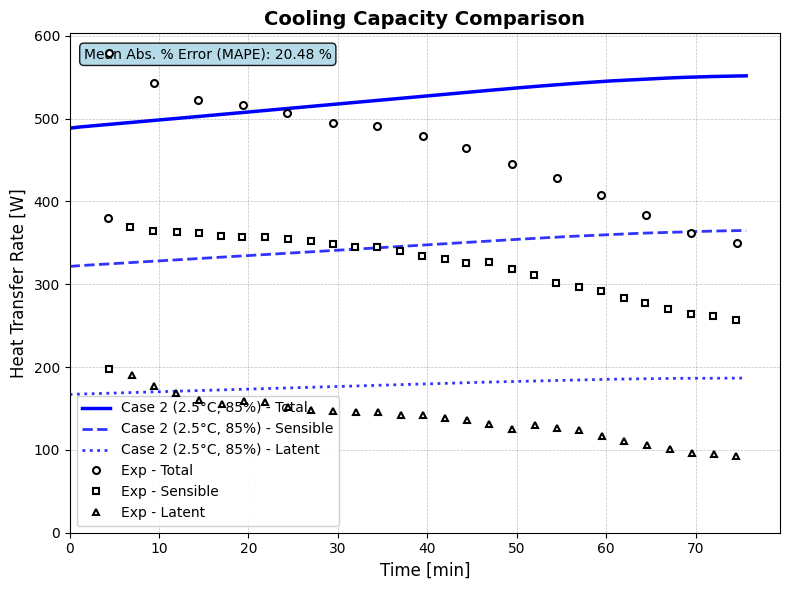

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modules
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel

#############################################################################
# 1. Define Global Parameters (Hardware/Geometry - constant for all tests)
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=20.0,  # [s]
    gravity=9.81,   # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    correction_factor_h_conv_air=0.55,
    correction_factor_surface_density=1.5,
    correction_factor_eta_fin=0.9,
    correction_factor_k_frost=1,
    correction_factor_pressure_loss=3.2,  # [-]


    # Geometry Parameters
    fin_pitch=0.0025,               # [m]
    fin_height=0.152,               # [m]
    fin_length=0.045,               # [m]
    fin_thickness=0.0002,           # [m]
    fin_amount=128,                 # [-]
    fin_thermal_conductivity=200.0, # [W/mK]
    tube_outer_diameter=0.010,      # [m]
    tube_inner_diameter=0.008,      # [m]
    tube_layers=2,                  # [-]
    tubes_per_layer=6,              # [-]
    tube_thermal_conductivity=400,  # [W/mK]

    alpha_0=4300.0,  # [W/m^2K]
)

#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the simulation for a specific set of boundary conditions.
    Returns a DataFrame of results and the assigned color for plotting.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    # Dummy refrigerant inputs (since T_surface is constant/forced)
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    air_inputs = AirInputs(
        T_in = 273.15 + T_air_C,  # Convert to K
        p_in = 101325.0,          # [Pa]
        R_in = RH_in,             # [-]
    )

    inputs = FrostEvaporatorInputs(
        air_inputs=air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    # refrigerant_model = RefrigerantModel(params, propane_RP) # Not strictly needed if forcing T_surf
    hmt_model = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)

    # --- Initial State ---
    state = FrostEvaporatorState()
    state = FrostEvaporatorState()
    state.hmt.set("T_frost_surface", 268)
    state.hmt.set("T_frost_base", 268)
    state.air.set("T_out", inputs.air.T_in)
    state.air.set("reynolds", 2000)
    state.air.set("T_dew_point", 260)
    state.frost.set("density", 100)
    state.frost.set("mass", 1e-9)

    state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

    # FORCE SURFACE TEMPERATURE (The paper's method)
    T_surface_kelvin = 273.15 + T_surf_C
    state.refrigerant.set("T_in", T_surface_kelvin)
    state.refrigerant.set("T_out", T_surface_kelvin)

    # Initial Step
    frost_model.step_forward(state, inputs)

    # --- Time Loop ---
    states_history = []
    simulation_duration_sec = int(duration_mins * 60)
    
    # Use a unique description for the progress bar
    for j in tqdm(range(simulation_duration_sec), desc=case_name):
        converged = False
        
        # Inner loop to converge
        for i in range(200):
            T_prev = state.hmt.T_frost_surface

            # Run model updates
            frost_model.update_properties(state, inputs)
            air_model.update_properties(state, inputs)
            hmt_model.update_properties(state, inputs)
            thermo_model.update_properties(state, inputs)
            
            T_new = state.hmt.T_frost_surface
            
            if abs(T_new - T_prev) < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residuum: {abs(T_new - T_prev)}")
            break 

        if state.air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        states_history.append(state.copy())
        
        # Physical step forward
        frost_model.step_forward(state, inputs)

    # --- Post-Process Data into DataFrame ---
    # Create time axis in Minutes
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    data = {
        # Heat Transfer
        'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
        'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################

# Define the 3 simulations from the paper
# Format: (Name, T_air_in_C, RH_in, T_surf_C, Duration_mins, PlotColor)
simulations_config = [
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 3.8,  "blue"),
]

results = {}

# Run them all
for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    df_res, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)
    results[name] = {'df': df_res, 'color': color_res}



################################################################################
# Get Deviation to Experiment
################################################################################


# Data Locations
EXP_FOLDER_PATH = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert"
EXP_FILENAME = "cooling_capacity.csv"

# Initialization
exp_data = {'Total': [], 'Sensible': [], 'Latent': []}
cat_names = ['Total', 'Sensible', 'Latent']
deviation_report = ""

full_path = os.path.join(EXP_FOLDER_PATH, EXP_FILENAME)

## Load & Process Experimental Data ##
ext_df = pd.read_csv(full_path, header=None)
ext_df.columns = ['time', 'value']
ext_df = ext_df.apply(pd.to_numeric, errors='coerce').dropna()

# Split curves based on time reset
ext_df['diff'] = ext_df['time'].diff()
split_indices = ext_df.index[ext_df['diff'] < 0].tolist()
boundaries = [0] + split_indices + [len(ext_df)]

# Group chunks into Total/Sensible/Latent
for i in range(len(boundaries) - 1):
    start, end = boundaries[i], boundaries[i+1]
    sub_df = ext_df.iloc[start:end]
    cat_name = cat_names[i % 3]
    exp_data[cat_name].append(sub_df)



## Calculate Deviation (The "Single Number") ##
case2_key = next((k for k in results.keys() if k.startswith('Case 2')), None)

df_sim = results[case2_key]['df']
    
exp_total_df = pd.concat(exp_data['Total'])

# Interpolate Simulation data to Experimental Timestamps
sim_interpolated = np.interp(
    exp_total_df['time'], 
    df_sim.index, 
    df_sim['Q_dot_total']
)

# Calculate Mean Absolute Percentage Error (MAPE)
abs_diff = np.abs(sim_interpolated - exp_total_df['value'])
# Filter small experimental values to avoid huge errors near zero
mask = exp_total_df['value'] > 1e-3 
mape_vals = abs_diff[mask] / exp_total_df['value'][mask]
mape = np.mean(mape_vals) * 100

# Root Mean Square Error (RMSE) for reference
rmse = np.sqrt(np.mean(abs_diff**2))

deviation_report = (
    f"--- DEVIATION REPORT (Case 2 vs Exp) ---\n"
    f"Metric: Total Cooling Capacity\n"
    f"Mean Abs. % Error (MAPE): {mape:.2f} %\n"
    f"RMSE: {rmse:.2f} W"
)
print("\n" + deviation_report)


## Plotting ##
plt.figure(figsize=(8, 6), dpi=100)

# A. Plot Simulation (Only Case 2 for simplicity as it is the focus of deviation)
data = results[case2_key]
df = data['df']
color = data['color']
    
# Total
plt.plot(df.index, df['Q_dot_total'], color=color, ls='-', lw=2.5, label=f"{case2_key} - Total")
# Sensible
plt.plot(df.index, df['Q_dot_sens'], color=color, ls='--', lw=2.0, alpha=0.8, label=f"{case2_key} - Sensible")
# Latent
plt.plot(df.index, df['Q_dot_total'] - df['Q_dot_sens'], color=color, ls=':', lw=2.0, alpha=0.8, label=f"{case2_key} - Latent")

# B. Plot Experiment
markers = {'Total': 'o', 'Sensible': 's', 'Latent': '^'}
seen_labels = set()
for cat_name in cat_names:
    if exp_data[cat_name]:
        full_cat_df = pd.concat(exp_data[cat_name])
        lbl_str = f"Exp - {cat_name}"
        final_label = lbl_str if lbl_str not in seen_labels else None
        if final_label:
            seen_labels.add(final_label)
            
        plt.plot(
            full_cat_df['time'], 
            full_cat_df['value'], 
            ls='None', marker=markers[cat_name], color='k', mfc='w', mew=1.5, ms=5, zorder=10,
            label=final_label
        )

# C. Styling
plt.title("Cooling Capacity Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Heat Transfer Rate [W]", fontsize=12)

# Annotate the Single Number (MAPE) on the plot
if deviation_report:
    mape_line = deviation_report.split('\n')[2]
    plt.annotate(
        mape_line, 
        xy=(0.02, 0.95), xycoords='axes fraction', 
        bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black", alpha=0.9), 
        fontsize=10
    )

plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

--- Loading Experimental Data ---

--- STARTING OPTIMIZATION (Nelder-Mead) ---
Eval: [0.8779 1.4431 0.9429 1.2753 2.1181] -> RMSE: 254.1861
Eval: [1.399  0.602  0.8323 0.8303 3.6017] -> RMSE: 164.7463
Eval: [0.5044 1.9733 0.6353 1.5064 1.1902] -> RMSE: 96.8189
Eval: [0.6864 0.6713 0.9306 1.4432 2.4194] -> RMSE: 140.6954
Eval: [1.3024 1.3889 0.6099 1.9218 1.9564] -> RMSE: 247.3320
Eval: [0.4142 1.1958 0.5504 0.9382 1.3918] -> RMSE: 164.4749
Eval: [0.4748 1.0328 0.715  1.0298 2.7944] -> RMSE: 96.1299
Eval: [0.5135 2.0574 0.5007 1.6158 3.3442] -> RMSE: 153.7307
Eval: [0.666  1.8732 0.5041 1.4774 3.6871] -> RMSE: 99.3342
Eval: [0.5735 0.6808 0.7027 1.1211 4.0841] -> RMSE: 68.0710
Eval: [1.2754 2.4377 0.7763 1.7247 1.6782] -> RMSE: 342.6993
Eval: [0.9957 2.1397 0.7389 0.8586 4.0073] -> RMSE: 181.4200
Eval: [0.4256 2.1637 0.5761 0.7643 1.1953] -> RMSE: 152.8647
Eval: [0.9317 1.7298 0.6225 0.7763 2.9285] -> RMSE: 133.2741
Eval: [1.067  1.8104 0.816  1.1728 4.5692] -> RMSE: 210.4828
Eval: [0.7

Case 2 (Optimization): 100%|██████████| 228/228 [00:07<00:00, 32.41it/s]


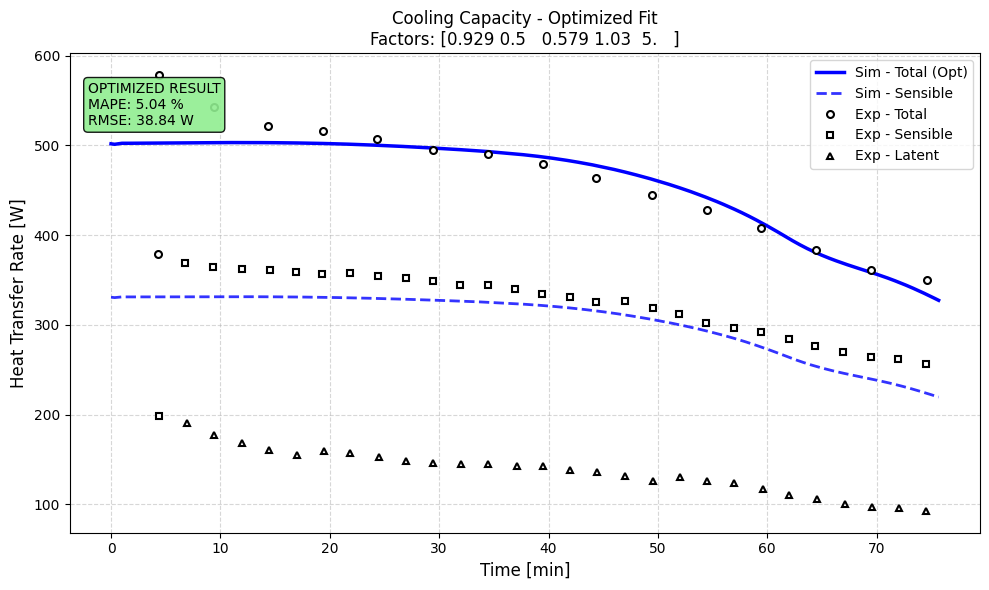

In [5]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize, Bounds

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modules
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)
from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel

# =============================================================================
# 0. CONFIGURATION & RANGES
# =============================================================================

# Define the ranges [min, max] for the optimizer
OPTIMIZATION_BOUNDS = {
    'h_conv_air':      (0.4, 1.5),   # Correction factor for Air Convection
    'surface_density': (0.5, 2.5),   # Correction factor for Surface Density
    'eta_fin':         (0.5, 1.0),   # Correction factor for Fin Efficiency
    'k_frost':         (0.5, 2.0),   # Correction factor for Frost Conductivity
    'pressure_loss':   (1.0, 5.0),   # Correction factor for Pressure Loss
}

# Initial Guess (Starting point for the optimizer)
INITIAL_GUESS = [0.55, 1.5, 0.9, 1.0, 3.2]

# Case Configuration
CASE_CONFIG = ("Case 2 (Optimization)", 2.5, 0.85, -10.0, 3.8, "blue")

# Experimental Data Config
EXP_FOLDER_PATH = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert"
EXP_FILENAME = "cooling_capacity.csv"

# =============================================================================
# 1. SETUP PARAMETERS (Base Object)
# =============================================================================
params = FrostEvaporatorParameters(
    # General
    time_step=20.0,
    gravity=9.81,

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Initial Placeholders (Will be overwritten by optimizer)
    correction_factor_h_conv_air=INITIAL_GUESS[0],
    correction_factor_surface_density=INITIAL_GUESS[1],
    correction_factor_eta_fin=INITIAL_GUESS[2],
    correction_factor_k_frost=INITIAL_GUESS[3],
    correction_factor_pressure_loss=INITIAL_GUESS[4],

    # Geometry Parameters
    fin_pitch=0.0025,
    fin_height=0.152,
    fin_length=0.045,
    fin_thickness=0.0002,
    fin_amount=128,
    fin_thermal_conductivity=200.0,
    tube_outer_diameter=0.010,
    tube_inner_diameter=0.008,
    tube_layers=2,
    tubes_per_layer=6,
    tube_thermal_conductivity=400,
    alpha_0=4300.0,
)

# =============================================================================
# 2. PRE-LOAD EXPERIMENTAL DATA (Run Once)
# =============================================================================
print("--- Loading Experimental Data ---")
full_path = os.path.join(EXP_FOLDER_PATH, EXP_FILENAME)
ext_df = pd.read_csv(full_path, header=None)
ext_df.columns = ['time', 'value']
ext_df = ext_df.apply(pd.to_numeric, errors='coerce').dropna()

# Split curves
ext_df['diff'] = ext_df['time'].diff()
split_indices = ext_df.index[ext_df['diff'] < 0].tolist()
boundaries = [0] + split_indices + [len(ext_df)]

exp_data_dict = {'Total': [], 'Sensible': [], 'Latent': []}
cat_names = ['Total', 'Sensible', 'Latent']

for i in range(len(boundaries) - 1):
    start, end = boundaries[i], boundaries[i+1]
    sub_df = ext_df.iloc[start:end]
    cat_name = cat_names[i % 3]
    exp_data_dict[cat_name].append(sub_df)

exp_total_df = pd.concat(exp_data_dict['Total'])

# =============================================================================
# 3. SIMULATION FUNCTION
# =============================================================================
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, current_params, silent=False):
    """
    Runs the simulation. 
    If silent=True, suppresses print statements and tqdm bars for optimization speed.
    """
    
    # --- Setup Inputs ---
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)
    air_inputs = AirInputs(
        T_in = 273.15 + T_air_C,
        p_in = 101325.0,
        R_in = RH_in,
    )
    inputs = FrostEvaporatorInputs(air_inputs=air_inputs, refrigerant_inputs=refrigerant_inputs)

    # --- Instantiate Models ---
    frost_model = FrostModel(current_params)
    air_model   = AirModel(current_params)
    hmt_model = HeatMassTransferModel(current_params)
    thermo_model = ThermoModel(current_params)

    # --- Initial State ---
    state = FrostEvaporatorState()
    state.hmt.set("T_frost_surface", 268)
    state.hmt.set("T_frost_base", 268)
    state.air.set("T_out", inputs.air.T_in)
    state.air.set("reynolds", 2000)
    state.air.set("T_dew_point", 260)
    state.frost.set("density", 100)
    state.frost.set("mass", 1e-9)

    state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)
    T_surface_kelvin = 273.15 + T_surf_C
    state.refrigerant.set("T_in", T_surface_kelvin)
    state.refrigerant.set("T_out", T_surface_kelvin)

    frost_model.step_forward(state, inputs)

    # --- Time Loop ---
    states_history = []
    simulation_duration_sec = int(duration_mins * 60)
    
    iterator = range(simulation_duration_sec)
    if not silent:
        iterator = tqdm(iterator, desc=case_name)

    for j in iterator:
        converged = False
        for i in range(200):
            T_prev = state.hmt.T_frost_surface
            frost_model.update_properties(state, inputs)
            air_model.update_properties(state, inputs)
            hmt_model.update_properties(state, inputs)
            thermo_model.update_properties(state, inputs)
            T_new = state.hmt.T_frost_surface
            
            if abs(T_new - T_prev) < 1e-3:
                converged = True
                break
        
        if not converged and not silent:
            print(f"!!! CRASH in {case_name} at step {j} !!!")
            break 
        if state.air.m_dot_humid < 1e-3:
            if not silent: print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        states_history.append(state.copy())
        frost_model.step_forward(state, inputs)

    # --- Post-Process ---
    time_axis = [i * current_params.time_step / 60 for i in range(len(states_history))]
    data = {
        'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
        'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],
    }
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df

# =============================================================================
# 4. OPTIMIZATION LOGIC (UPDATED)
# =============================================================================

def calculate_error(df_sim, df_exp):
    """Calculates RMSE between simulation and experiment."""
    if df_sim.empty:
        return 999999.0 # Penalty for crash

    # Interpolate Simulation data to Experimental Timestamps
    sim_interpolated = np.interp(
        df_exp['time'], 
        df_sim.index, 
        df_sim['Q_dot_total']
    )
    
    abs_diff = np.abs(sim_interpolated - df_exp['value'])
    rmse = np.sqrt(np.mean(abs_diff**2))
    return rmse

def objective_function(x):
    """
    x = [h_conv, surf_dens, eta_fin, k_frost, p_loss]
    """
    # --- 1. Manual Bounds Check (Soft Constraints) ---
    # Nelder-Mead doesn't strictly obey bounds, so we penalize if it goes outside.
    # This prevents the simulation from crashing with negative numbers.
    bounds_keys = ['h_conv_air', 'surface_density', 'eta_fin', 'k_frost', 'pressure_loss']
    for i, key in enumerate(bounds_keys):
        low, high = OPTIMIZATION_BOUNDS[key]
        if x[i] < low or x[i] > high:
            return 10000.0 + (abs(x[i] - low) * 1000) # Soft penalty
    
    # --- 2. Update Parameters ---
    params.correction_factor_h_conv_air      = x[0]
    params.correction_factor_surface_density = x[1]
    params.correction_factor_eta_fin         = x[2]
    params.correction_factor_k_frost         = x[3]
    params.correction_factor_pressure_loss   = x[4]

    # --- 3. Run Simulation ---
    name, t_in, rh, t_surf, dur, _ = CASE_CONFIG
    try:
        # Run silent
        df_res = run_simulation_case(name, t_in, rh, t_surf, dur, params, silent=True)
        
        # --- 4. Calculate Error ---
        error = calculate_error(df_res, exp_total_df)
        
        # Print with more precision to see changes
        print(f"Eval: {np.round(x, 4)} -> RMSE: {error:.4f}")
        return error
        
    except Exception as e:
        print(f"Error: {e}")
        return 999999.0

# --- PREPARE OPTIMIZER ---
print("\n--- STARTING OPTIMIZATION (Nelder-Mead) ---")

# Nelder-Mead is "Gradient-Free" - much better for messy engineering simulations
# result = minimize(
#     objective_function, 
#     INITIAL_GUESS, 
#     method='Nelder-Mead',  # <--- CHANGED THIS
#     options={'disp': True, 'maxiter': 50, 'xatol': 0.01, 'fatol': 0.1} 
# )

bounds_list = [v for v in OPTIMIZATION_BOUNDS.values()]

from scipy.optimize import differential_evolution
result = differential_evolution(
    objective_function, 
    bounds_list, # Differential Evolution requires bounds to be defined here
    strategy='best1bin',
    maxiter=10,  # Run for 50 generations (populations)
    popsize=25,  # Use a population of 15 * 5 = 75 trial vectors
    tol=0.01,
    disp=True
)

print("\n" + "="*40)
print("OPTIMIZATION COMPLETE")
print("="*40)
print(f"Success: {result.success}")
print(f"Best RMSE: {result.fun:.4f}")
print("Best Parameters:")
print(f"  h_conv_air:      {result.x[0]:.4f}")
print(f"  surface_density: {result.x[1]:.4f}")
print(f"  eta_fin:         {result.x[2]:.4f}")
print(f"  k_frost:         {result.x[3]:.4f}")
print(f"  pressure_loss:   {result.x[4]:.4f}")
print("="*40 + "\n")


# =============================================================================
# 5. FINAL RUN & PLOTTING
# =============================================================================

# Set parameters to the best found values
params.correction_factor_h_conv_air = result.x[0]
params.correction_factor_surface_density = result.x[1]
params.correction_factor_eta_fin = result.x[2]
params.correction_factor_k_frost = result.x[3]
params.correction_factor_pressure_loss = result.x[4]

# Run one final time with progress bar and logging
print("Running final simulation with optimized parameters...")
name, t_in, rh, t_surf, dur, col = CASE_CONFIG
final_df = run_simulation_case(name, t_in, rh, t_surf, dur, params, silent=False)

# Calculate final deviation report
final_rmse = calculate_error(final_df, exp_total_df)

# Calc MAPE for reporting
sim_interpolated = np.interp(exp_total_df['time'], final_df.index, final_df['Q_dot_total'])
abs_diff = np.abs(sim_interpolated - exp_total_df['value'])
mask = exp_total_df['value'] > 1e-3 
mape_vals = abs_diff[mask] / exp_total_df['value'][mask]
final_mape = np.mean(mape_vals) * 100

deviation_report = (
    f"OPTIMIZED RESULT\n"
    f"MAPE: {final_mape:.2f} %\n"
    f"RMSE: {final_rmse:.2f} W"
)

# Plotting
plt.figure(figsize=(10, 6), dpi=100)

# Simulation
plt.plot(final_df.index, final_df['Q_dot_total'], color=col, ls='-', lw=2.5, label="Sim - Total (Opt)")
plt.plot(final_df.index, final_df['Q_dot_sens'], color=col, ls='--', lw=2.0, alpha=0.8, label="Sim - Sensible")

# Experiment
markers = {'Total': 'o', 'Sensible': 's', 'Latent': '^'}
seen_labels = set()
for cat_name in cat_names:
    if exp_data_dict[cat_name]:
        full_cat_df = pd.concat(exp_data_dict[cat_name])
        lbl_str = f"Exp - {cat_name}"
        final_label = lbl_str if lbl_str not in seen_labels else None
        if final_label: seen_labels.add(final_label)
        
        plt.plot(
            full_cat_df['time'], 
            full_cat_df['value'], 
            ls='None', marker=markers[cat_name], color='k', mfc='w', mew=1.5, ms=5,
            label=final_label
        )

# Styling
plt.title(f"Cooling Capacity - Optimized Fit\nFactors: {np.round(result.x, 3)}", fontsize=12)
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Heat Transfer Rate [W]", fontsize=12)

plt.annotate(
    deviation_report, 
    xy=(0.02, 0.85), xycoords='axes fraction', 
    bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="black", alpha=0.9), 
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [4]:
#############################################################################
# 4. Plotting (Combined)
#############################################################################

# Plot Configuration (Row, Col, Variables, Title)
plots_config = [
    # --- ROW 1 ---
    (1, 1, ['T_air_in', 'T_air_out', 'T_frost_surf', 'T_refrigerant_in'], "Temperatures [K]"), 
    (1, 2, ['Q_dot_total', 'Q_dot_sens'], "Heat Transfer [W]"),
    (1, 3, ['p_delta'], "Pressure Difference [Pa]"),
    
    # --- ROW 2 ---
    (2, 1, ['vol_flow'], "Volume Flow [m³/h]"),
    (2, 2, ['velocity'], "Air Velocity [m/s]"),
    (2, 3, ['m_dot'], "Mass Flow [kg/s]"),
    
    # --- ROW 3 ---
    (3, 1, ['W_in', 'W_out', 'W_frost_surface_sat'], "Abs. Humidity [kg/kg]"),
    (3, 2, ['h_conv'], "Air h_conv [W/m²K]"),
    (3, 3, ['eta_fin'], "Fin Efficiency [-]"),
    
    # --- ROW 4 ---
    (4, 1, ['thickness'], "Frost Thickness [m]"),
    (4, 2, ['density'], "Frost Density [kg/m³]"),
    (4, 3, ['space'], "Space Between Frost [m]"),

    # --- ROW 5 ---
    (5, 1, ['mass'], "Frost Mass [kg]")
]

fig = make_subplots(
    rows=5, cols=3, 
    subplot_titles=[p[3] for p in plots_config],
    vertical_spacing=0.08, horizontal_spacing=0.05
)

# Iterate over simulation results
for case_name, res_data in results.items():
    df = res_data['df']
    color = res_data['color']
    
    # Iterate over plot configuration
    for row, col, cols_to_plot, title in plots_config:
        for col_name in cols_to_plot:
            
            # Styling: Dashed lines for specific secondary variables to distinguish them
            line_dash = 'solid'
            if 'out' in col_name and 'air' in col_name: line_dash = 'dot'
            if 'sens' in col_name: line_dash = 'dot'
            if 'frost_sat' in col_name: line_dash = 'dash'
            
            # Construct a trace name: "Variable (Case Name)"
            trace_name = f"{col_name} ({case_name})"
            
            fig.add_trace(
                go.Scatter(
                    x=df.index, 
                    y=df[col_name], 
                    name=trace_name,
                    line=dict(color=color, dash=line_dash, width=1.5),
                    legendgroup=case_name, # Grouping allows toggling whole cases if desired
                    showlegend=(row==1 and col==1) # Only show legend once to avoid clutter? 
                    # Or remove 'showlegend=...' to show everything
                ),
                row=row, col=col
            )

# ---------------------------------------------------------
# Layout & Final Touches
# ---------------------------------------------------------
fig.update_layout(
    height=2000, width=1400, 
    title_text="Comparison of Frost Growth Simulations (Paper Reproduction)",
    hovermode="x unified",
    showlegend=False 
)

fig.update_xaxes(matches='x', title_text="Time [min]")
# Ensure space plot goes to zero
fig.update_yaxes(rangemode="tozero", row=4, col=3)

fig.show()

# Full Experiment recalculation

In [3]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modules
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel

#############################################################################
# 1. Define Global Parameters (Hardware/Geometry - constant for all tests)
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=20.0,  # [s]
    gravity=9.81,   # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",

    # correction_factor_h_conv_air=0.7869,
    # correction_factor_surface_density=0.7089,
    # correction_factor_eta_fin=0.6065,
    # correction_factor_k_frost=1.2526,
    # correction_factor_pressure_loss=3.4811,

    correction_factor_h_conv_air=0.7,
    correction_factor_surface_density=1,
    correction_factor_eta_fin=1,
    correction_factor_k_frost=1,
    correction_factor_pressure_loss=3.4,

    # Geometry Parameters
    fin_pitch=0.0025,               # [m]
    fin_height=0.152,               # [m]
    fin_length=0.045,               # [m]
    fin_thickness=0.0002,           # [m]
    fin_amount=128,                 # [-]
    fin_thermal_conductivity=200.0, # [W/mK]
    tube_outer_diameter=0.010,      # [m]
    tube_inner_diameter=0.008,      # [m]
    tube_layers=2,                  # [-]
    tubes_per_layer=6,              # [-]
    tube_thermal_conductivity=400,  # [W/mK]

    alpha_0=4300.0,  # [W/m^2K]
)

#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the simulation for a specific set of boundary conditions.
    Returns a DataFrame of results and the assigned color for plotting.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    # Dummy refrigerant inputs (since T_surface is constant/forced)
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    air_inputs = AirInputs(
        T_in = 273.15 + T_air_C,  # Convert to K
        p_in = 101325.0,          # [Pa]
        R_in = RH_in,             # [-]
    )

    inputs = FrostEvaporatorInputs(
        air_inputs=air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    # refrigerant_model = RefrigerantModel(params, propane_RP) # Not strictly needed if forcing T_surf
    hmt_model = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)

    # --- Initial State ---
    state = FrostEvaporatorState()
    state = FrostEvaporatorState()
    state.hmt.set("T_frost_surface", 268)
    state.hmt.set("T_frost_base", 268)
    state.air.set("T_out", inputs.air.T_in)
    state.air.set("reynolds", 2000)
    state.air.set("T_dew_point", 260)
    state.frost.set("density", 100)
    state.frost.set("mass", 1e-9)

    state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

    # FORCE SURFACE TEMPERATURE (The paper's method)
    T_surface_kelvin = 273.15 + T_surf_C
    state.refrigerant.set("T_in", T_surface_kelvin)
    state.refrigerant.set("T_out", T_surface_kelvin)

    # Initial Step
    frost_model.step_forward(state, inputs)

    # --- Time Loop ---
    states_history = []
    simulation_duration_sec = int(duration_mins * 3)
    
    # Use a unique description for the progress bar
    for j in tqdm(range(simulation_duration_sec), desc=case_name):
        converged = False
        
        # Inner loop to converge
        for i in range(200):
            T_prev = state.hmt.T_frost_surface

            # Run model updates
            frost_model.update_properties(state, inputs)
            air_model.update_properties(state, inputs)
            hmt_model.update_properties(state, inputs)
            thermo_model.update_properties(state, inputs)
            
            T_new = state.hmt.T_frost_surface
            
            if abs(T_new - T_prev) < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residuum: {abs(T_new - T_prev)}")
            break 

        if state.air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        states_history.append(state.copy())
        
        # Physical step forward
        frost_model.step_forward(state, inputs)

    # --- Post-Process Data into DataFrame ---
    # Create time axis in Minutes
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    data = {
        # Temps
        'T_air_in': inputs.air.T_in, 
        'T_air_out': [s.air.T_out for s in states_history],
        'T_frost_surf': [s.hmt.T_frost_surface for s in states_history],
        'T_refrigerant_in' : [s.refrigerant.T_in for s in states_history],
        'T_refrigerant_out' : [s.refrigerant.T_out for s in states_history],
        
        # Humidity
        'W_in': state.air.W_in, 
        'W_out': [s.air.W_out for s in states_history],
        'W_frost_surface_sat': [s.air.W_frost_surface_sat for s in states_history],
        
        # Heat Transfer
        'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
        'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],
        
        # --- FROST PROPERTIES ---
        'thickness': [s.frost.thickness for s in states_history],
        'density': [s.frost.density for s in states_history],
        'space': [s.frost.space_between_frost for s in states_history],
        'mass': [s.frost.mass for s in states_history],
        'm_dot_densification': [s.hmt.m_dot_densification for s in states_history],
        'm_dot_thickening': [s.hmt.m_dot_thickening for s in states_history],
        
        # Flow/Physics
        'h_conv': [s.air.h_conv for s in states_history],
        'eta_fin': [s.hmt.eta_fin for s in states_history],
        'velocity': [s.air.velocity for s in states_history],
        'm_dot': [s.air.m_dot_humid for s in states_history],
        'p_delta': [s.air.p_in - params.ambient_pressure for s in states_history],
        # Vol flow in m3/h
        'vol_flow': [3600 * s.air.m_dot_humid / s.air.density_avg for s in states_history]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################

# Define the 3 simulations from the paper
# Format: (Name, T_air_in_C, RH_in, T_surf_C, Duration_mins, PlotColor)
simulations_config = [
    # ("Case 1 (7°C, 85%)",   7.0, 0.85, -10.0, 42,  "red"),
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 76,  "blue"),
    # ("Case 3 (2.5°C, 85%)", 2.5, 0.85, -5.0,  120, "green"),
]

results = {}

# Run them all
for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    df_res, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)
    results[name] = {'df': df_res, 'color': color_res}

--- Starting Simulation: Case 2 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%):  89%|████████▊ | 202/228 [00:11<00:01, 17.42it/s]

!!! Air Choke in Case 2 (2.5°C, 85%) at step 202 !!!


Loaded experimental data for: vol_flow


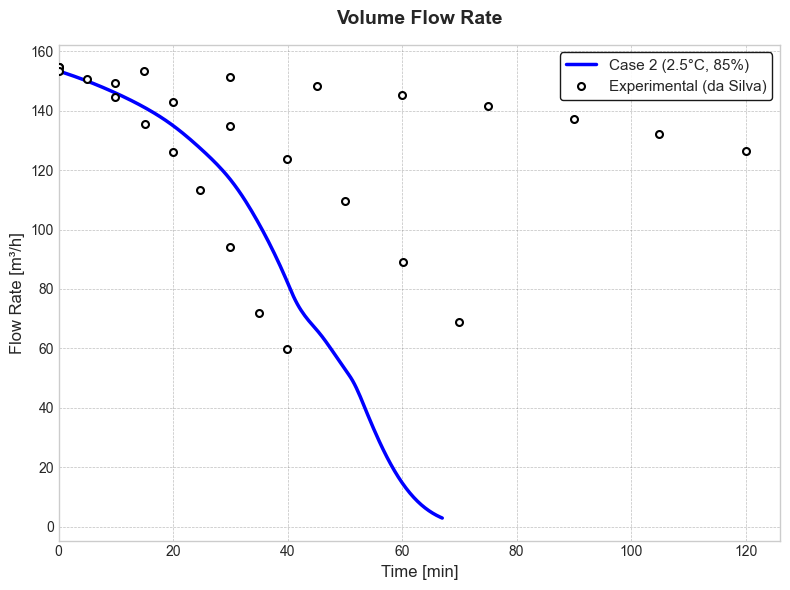

Loaded experimental data for: p_delta


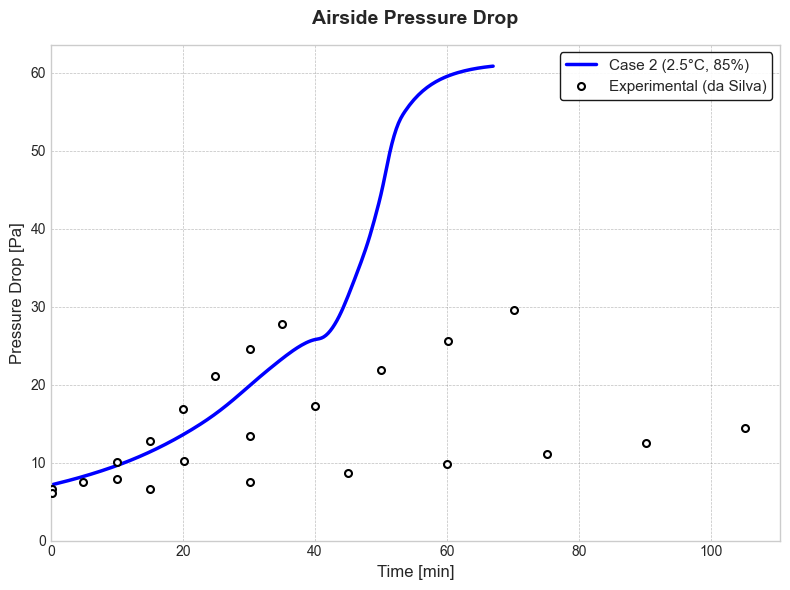

Processing stacked curves with colors for thickness...


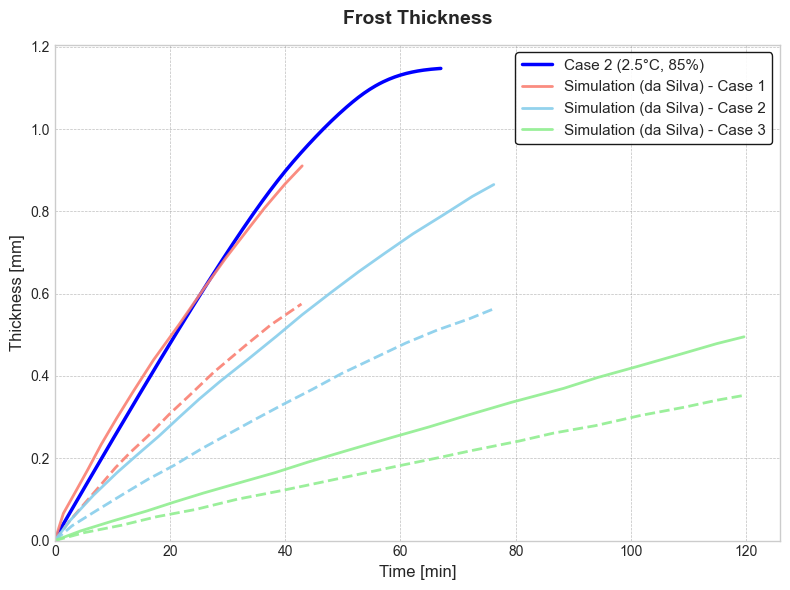

Loaded experimental data for: mass


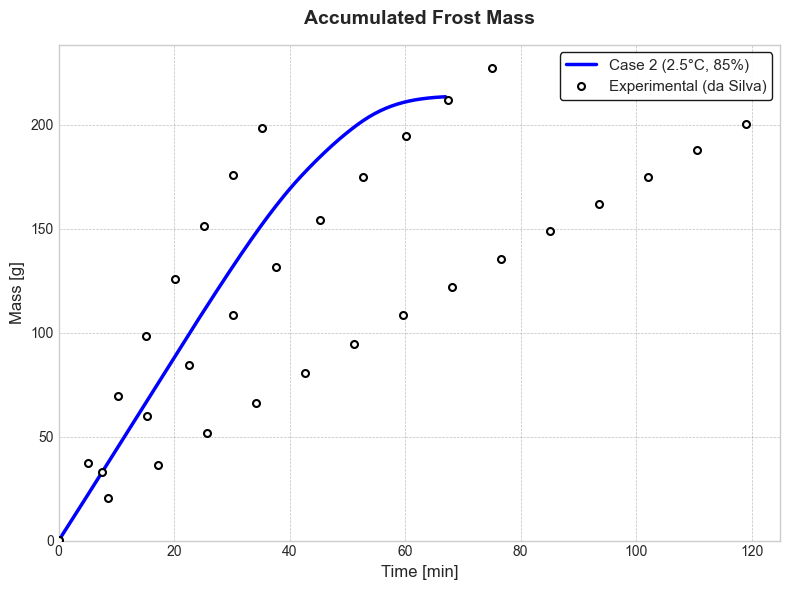

Loaded experimental data: cooling_capacity.csv (3 curves found)


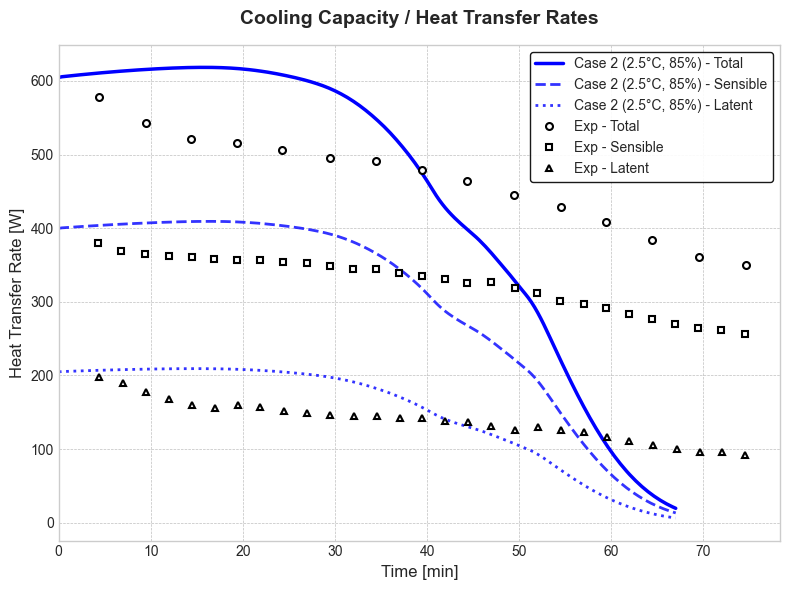

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Optional: Set a clean style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('fast')

# ---------------------------------------------------------
# DATA LOCATIONS & MAPPING
# ---------------------------------------------------------
EXP_FOLDER_PATH = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert"

exp_file_map = {
    'vol_flow': 'air_flow_rate.csv',
    'p_delta': 'air_pressure_drop.csv',
    'mass': 'frost_mass.csv',
    'thickness': 'frost_thickness_simulation.csv' 
}

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
plot_specs = [
    ('vol_flow',  "Volume Flow Rate",       "Flow Rate [m³/h]", 1.0),
    ('p_delta',   "Airside Pressure Drop",  "Pressure Drop [Pa]", 1.0),
    ('thickness', "Frost Thickness",        "Thickness [mm]",   1000.0),
    ('mass',      "Accumulated Frost Mass", "Mass [g]",         1000.0),
]

# ---------------------------------------------------------
# PLOTTING LOOP
# ---------------------------------------------------------
for col_name, title, y_label, multiplier in plot_specs:
    
    plt.figure(figsize=(8, 6), dpi=100)
    
    # 1. PLOT SIMULATION DATA
    # -----------------------
    if 'results' in locals():
        for case_name, data in results.items():
            df = data['df']
            color = data['color']
            
            plt.plot(
                df.index, 
                df[col_name] * multiplier, 
                label=case_name, 
                color=color, 
                linewidth=2.5,
                linestyle='-'
            )
    else:
        print("Warning: 'results' dictionary not found. Skipping simulation lines.")

    # 2. PLOT EXPERIMENTAL / EXTERNAL DATA
    # ------------------------------------
    if col_name in exp_file_map:
        filename = exp_file_map[col_name]
        full_path = os.path.join(EXP_FOLDER_PATH, filename)
        
        if os.path.exists(full_path):
            try:
                # Load CSV without header
                ext_df = pd.read_csv(full_path, header=None)
                ext_df.columns = ['time', 'value']
                
                # Ensure numeric
                ext_df['time'] = pd.to_numeric(ext_df['time'], errors='coerce')
                ext_df['value'] = pd.to_numeric(ext_df['value'], errors='coerce')
                
                # --- SPECIAL LOGIC FOR THICKNESS (Split Stacked Curves & Color) ---
                if col_name == 'thickness':
                    print(f"Processing stacked curves with colors for {col_name}...")
                    
                    # 1. Find indices where time resets (indicating a new curve)
                    ext_df['diff'] = ext_df['time'].diff()
                    split_indices = ext_df.index[ext_df['diff'] < 0].tolist()
                    boundaries = [0] + split_indices + [len(ext_df)]
                    
                    # Define colors for pairs (1-2, 3-4, 5-6)
                    # Using Matplotlib named colors: 'salmon' (light red), 'skyblue', 'lightgreen'
                    pair_colors = ['salmon', 'skyblue', 'lightgreen']
                    
                    curve_count = 1
                    for i in range(len(boundaries) - 1):
                        start_idx = boundaries[i]
                        end_idx = boundaries[i+1]
                        
                        # Extract the single curve chunk
                        sub_df = ext_df.iloc[start_idx:end_idx]
                        x_data = sub_df['time']
                        y_data = sub_df['value']
                        
                        # --- STYLING LOGIC ---
                        
                        # Determine Color based on pair group (Indices 0, 1, or 2)
                        color_idx = (curve_count - 1) // 2
                        # Safety check in case there are more than 6 curves defined
                        if color_idx < len(pair_colors):
                            line_color = pair_colors[color_idx]
                        else:
                            line_color = 'gray' # Fallback for curve 7+

                        # Determine Line Style (Odd=Solid, Even=Dashed)
                        line_style = '-' if (curve_count % 2 != 0) else '--'
                        
                        # Determine Label (Only label the start of a color group)
                        lbl = None
                        if curve_count == 1: lbl = 'Simulation (da Silva) - Case 1'
                        elif curve_count == 3: lbl = 'Simulation (da Silva) - Case 2'
                        elif curve_count == 5: lbl = 'Simulation (da Silva) - Case 3'
                        
                        plt.plot(
                            x_data, 
                            y_data, 
                            color=line_color, 
                            linestyle=line_style, 
                            linewidth=2.0,       # Slightly thicker for better visibility
                            alpha=0.9,           # High opacity for light colors
                            label=lbl
                        )
                        curve_count += 1
                        
                # --- STANDARD LOGIC FOR OTHER PLOTS (Black Dots) ---
                else:
                    plt.plot(
                        ext_df['time'], 
                        ext_df['value'], 
                        label='Experimental (da Silva)', 
                        color='black', 
                        marker='o', 
                        linestyle='None', 
                        markersize=5,
                        markerfacecolor='white',
                        markeredgewidth=1.5,
                        zorder=10
                    )
                    print(f"Loaded experimental data for: {col_name}")

            except Exception as e:
                print(f"Could not load {filename}: {e}")
        else:
            print(f"File not found: {full_path}")

    # ---------------------------------------------------------
    # FORMATTING
    # ---------------------------------------------------------
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time [min]", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    
    plt.xlim(left=0)
    if col_name in ['thickness', 'mass', 'p_delta']:
        plt.ylim(bottom=0)
        
    plt.legend(
        loc='best',
        fontsize=11, 
        frameon=True,
        fancybox=True, 
        framealpha=0.9,
        edgecolor='black'
    )
    
    plt.tight_layout()
    plt.show()



# ---------------------------------------------------------
# ADDITIONAL PLOT: Cooling Capacity (Total, Sensible, Latent)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=100)

# 1. PLOT SIMULATION DATA
# -----------------------
# Styles for differentiation: (Line Style, Alpha suffix for label)
sim_styles = {
    'total':    ('-',  1.0, 'Total'),
    'sensible': ('--', 0.7, 'Sensible'),
    'latent':   (':',  0.7, 'Latent')
}

if 'results' in locals():
    for case_name, data in results.items():
        if case_name.startswith('Case 2'):

            df = data['df']
            color = data['color']
            
            # Verify columns exist
            col_tot  = 'Q_dot_total'
            col_sens = 'Q_dot_sens'
            
            if col_tot in df.columns and col_sens in df.columns:
                # Calculate Latent Heat
                series_tot  = df[col_tot]
                series_sens = df[col_sens]
                series_lat  = series_tot - series_sens
                
                # Helper to plot each component
                # Total (Solid)
                plt.plot(df.index, series_tot, color=color, linestyle='-', linewidth=2.5,
                        label=f"{case_name} - Total")
                
                # Sensible (Dashed)
                plt.plot(df.index, series_sens, color=color, linestyle='--', linewidth=2.0, alpha=0.8,
                        label=f"{case_name} - Sensible")
                
                # Latent (Dotted)
                plt.plot(df.index, series_lat, color=color, linestyle=':', linewidth=2.0, alpha=0.8,
                        label=f"{case_name} - Latent")
            else:
                print(f"Warning: Heat transfer columns not found for case {case_name}")
else:
    print("Warning: 'results' dictionary not found. Skipping simulation lines.")

# 2. PLOT EXPERIMENTAL DATA
# -------------------------
exp_filename = "cooling_capacity.csv"
exp_path = os.path.join(EXP_FOLDER_PATH, exp_filename)

if os.path.exists(exp_path):
    try:
        # Load Data
        ext_df = pd.read_csv(exp_path, header=None)
        ext_df.columns = ['time', 'value']
        ext_df['time'] = pd.to_numeric(ext_df['time'], errors='coerce')
        ext_df['value'] = pd.to_numeric(ext_df['value'], errors='coerce')

        # Detect split points (where time jumps backwards)
        ext_df['diff'] = ext_df['time'].diff()
        split_indices = ext_df.index[ext_df['diff'] < 0].tolist()
        boundaries = [0] + split_indices + [len(ext_df)]

        # Defined Categories based on user description (Total -> Sensible -> Heat/Latent)
        # We assume the file repeats this pattern if there are multiple experiments
        cat_map = {
            0: ('Total',    'o'),  # Circle
            1: ('Sensible', 's'),  # Square
            2: ('Latent',   '^')   # Triangle
        }
        
        seen_labels = set() # To avoid duplicate legend entries

        for i in range(len(boundaries) - 1):
            start = boundaries[i]
            end = boundaries[i+1]
            sub_df = ext_df.iloc[start:end]

            # Determine category (0=Total, 1=Sensible, 2=Latent)
            cat_idx = i % 3
            cat_name, marker = cat_map[cat_idx]
            
            # Create a label only if we haven't seen it yet (to keep legend clean)
            lbl_str = f"Exp - {cat_name}"
            final_label = lbl_str if lbl_str not in seen_labels else None
            if final_label:
                seen_labels.add(final_label)

            plt.plot(
                sub_df['time'],
                sub_df['value'],
                label=final_label,
                color='black',
                marker=marker,
                linestyle='None',   # Points only
                markersize=5,
                markerfacecolor='white',
                markeredgewidth=1.5,
                zorder=10
            )
        print(f"Loaded experimental data: {exp_filename} ({len(boundaries)-1} curves found)")

    except Exception as e:
        print(f"Error loading {exp_filename}: {e}")
else:
    print(f"File not found: {exp_path}")

# 3. FORMATTING
# -------------
plt.title("Cooling Capacity / Heat Transfer Rates", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Heat Transfer Rate [W]", fontsize=12)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# Adjust Legend to fit outside if too crowded, or 'best'
plt.legend(
    loc='best',
    fontsize=10, 
    frameon=True,
    fancybox=True, 
    framealpha=0.9,
    edgecolor='black'
)

plt.xlim(left=0)
plt.tight_layout()
plt.show()

In [6]:
import CoolProp.CoolProp as CP

def print_separator(char='-', length=95):
    print(char * length)

def calculate_and_print_table():
    # Standard Atmosphärendruck in Pascal
    P_ATM = 101325 

    # Daten aus dem Paper (Table 1)
    # Format: (Test Nr, T_air [C], RH_air [%], T_surface [C], Paper_Supercooling_Val [C])
    data = [
        (1, 7.0, 85.0, -10.0, 14.5),
        (2, 2.5, 85.0, -10.0, 10.0),
        (3, 2.5, 74.0,  -5.0,  5.0)
    ]

    print("\n" + "="*35 + " NACHRECHNUNG DER PAPER-DATEN " + "="*30)
    print(f"{'Test':<5} {'T_air':<8} {'RH':<6} {'T_surf':<8} | {'T_tau (Calc)':<12} {'Supercool (Calc)':<18} {'Paper Wert':<12} {'Status'}")
    print_separator()

    for test_id, t_air, rh, t_surf, paper_val in data:
        # CoolProp benötigt SI-Einheiten (Kelvin, 0-1 für RH)
        # HAPropsSI Inputs: "Tdp" (Taupunkt) gesucht, gegeben "T", "R" (RH), "P"
        t_dew_k = CP.HAPropsSI('Tdp', 'T', t_air + 273.15, 'R', rh / 100.0, 'P', P_ATM)
        t_dew_c = t_dew_k - 273.15

        # Berechnung des "Supercooling Degree" (T_tau - T_surf)
        supercooling_calc = t_dew_c - t_surf
        
        # Abweichung prüfen
        diff = abs(supercooling_calc - paper_val)
        status = "OK" if diff < 0.3 else "ABWEICHUNG!"

        print(f"{test_id:<5} {t_air:<8.1f} {rh:<6.0f} {t_surf:<8.1f} | {t_dew_c:<12.2f} {supercooling_calc:<18.2f} {paper_val:<12.1f} {status}")

    print_separator()
    print("\n")

def solve_mystery_test_3():
    P_ATM = 101325
    
    # Zielwerte aus dem Paper für Test 3
    target_supercooling = 5.0
    t_surf = -5.0
    t_air = 2.5
    
    # Wenn Supercooling = 5.0 und T_surf = -5.0, muss der Taupunkt 0.0 C sein.
    target_t_dew = t_surf + target_supercooling # ergibt 0.0 C
    
    print("="*35 + " ANALYSE TEST NR. 3 " + "="*36)
    print(f"Ziel-Supercooling laut Paper: {target_supercooling:.1f} K")
    print(f"Dafür nötiger Taupunkt:       {target_t_dew:.1f} °C")
    print("-" * 95)
    
    # Rückwärtsrechnung: Welche RH ist nötig, um bei T_air=2.5 C einen Taupunkt von 0 C zu haben?
    # HAPropsSI Inputs: "R" (RH) gesucht, gegeben "T", "Tdp", "P"
    required_rh = CP.HAPropsSI('R', 'T', t_air + 273.15, 'Tdp', target_t_dew + 273.15, 'P', P_ATM)
    required_rh_percent = required_rh * 100

    print(f"Gegebene T_Luft:              {t_air:.1f} °C")
    print(f"Paper Angabe RH:              74.0 %  -> Führt zu Supercooling von 3.3 K (Falsch)")
    print(f"BERECHNETE NÖTIGE RH:         {required_rh_percent:.2f} %  -> Führt zu Supercooling von 5.0 K (Korrekt)")
    print("="*95 + "\n")

if __name__ == "__main__":
    calculate_and_print_table()
    solve_mystery_test_3()


=================================== NACHRECHNUNG DER PAPER-DATEN ==============================
Test  T_air    RH     T_surf   | T_tau (Calc) Supercool (Calc)   Paper Wert   Status
-----------------------------------------------------------------------------------------------
1     7.0      85     -10.0    | 4.65         14.65              14.5         OK
2     2.5      85     -10.0    | 0.24         10.24              10.0         OK
3     2.5      74     -5.0     | -1.47        3.53               5.0          ABWEICHUNG!
-----------------------------------------------------------------------------------------------


=================================== ANALYSE TEST NR. 3 ====================================
Ziel-Supercooling laut Paper: 5.0 K
Dafür nötiger Taupunkt:       0.0 °C
-----------------------------------------------------------------------------------------------
Gegebene T_Luft:              2.5 °C
Paper Angabe RH:              74.0 %  -> Führt zu Supercooling von 3.3 K (